# 01. Lorenz-63 Forward Model with Euler Method

이 노트북에서는 Lorenz-63 모델을 직접 구현하고, Euler 방법으로 시간적분한다.

이번 실습의 목표는 다음과 같다.

1. Lorenz-63 방정식을 이해한다.
2. Lorenz-63 RHS 함수를 구현한다.
3. Euler 방법으로 시간적분한다.
4. `x`, `y`, `z` 시계열을 확인한다.
5. Lorenz attractor를 시각화한다.
6. 초기조건이 조금 달라졌을 때 trajectory가 어떻게 달라지는지 확인한다.

이번 실습에서는 자료동화는 아직 수행하지 않는다.  
자료동화는 다음 노트북인 `02_lorenz63_3dvar_euler.ipynb`에서 진행한다.

## 1. 라이브러리 불러오기

이번 실습에서는 다음 라이브러리를 사용한다.

- `numpy`: 수치 계산
- `matplotlib`: 시각화
- `pathlib`: 경로 관리

출력 파일은 `outputs/figures/`, `outputs/trajectories/` 아래에 저장한다.

In [1]:
import sys
from pathlib import Path

# --- bootstrap: 프로젝트 루트의 src/ 를 sys.path 에 추가해 lorenz_da import 를 보장한다 ---
#     editable 설치 위치에 의존하지 않으므로, 프로젝트를 다른 경로로 옮겨도 동작한다.
_p = Path.cwd().resolve()
for _d in (_p, *_p.parents):
    if (_d / "pyproject.toml").exists() or (_d / ".git").exists():
        if str(_d / "src") not in sys.path:
            sys.path.insert(0, str(_d / "src"))
        break

import numpy as np
import matplotlib.pyplot as plt

from lorenz_da.models.lorenz63 import (
    lorenz63_rhs,
    lorenz63_default_initial_condition,
)
from lorenz_da.numerics.euler import (
    euler_step,
    integrate_euler,
)

from lorenz_da.utils.io import find_project_root, get_output_dirs

## 2. 프로젝트 경로 설정

노트북이 `notebooks/` 안에 있기 때문에, 실행 위치에 따라 상대경로가 달라질 수 있다.

아래 코드는 현재 작업 위치가 프로젝트 루트인지, `notebooks/` 디렉토리인지 확인한 뒤 프로젝트 루트 경로를 설정한다.

In [2]:
PROJECT_ROOT = find_project_root()
paths = get_output_dirs(PROJECT_ROOT)
FIGURE_DIR = paths["figures"]
TRAJECTORY_DIR = paths["trajectories"]
ASSIM_DIR = paths["assimilation"]
CKPT_DIR = paths["checkpoints"]

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/sanggyu/projects/lorenz-da-lab
Figure directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures


## 3. Lorenz-63 방정식

Lorenz-63 시스템은 세 개의 변수 `x`, `y`, `z`로 구성된 비선형 동역학계이다.

방정식은 다음과 같다.

$$
\frac{dx}{dt} = \sigma (y - x)
$$

$$
\frac{dy}{dt} = x(\rho - z) - y
$$

$$
\frac{dz}{dt} = xy - \beta z
$$

여기서 일반적으로 사용하는 표준 매개변수는 다음과 같다.

$$
\sigma = 10
$$

$$
\rho = 28
$$

$$
\beta = \frac{8}{3}
$$

Lorenz-63 시스템은 chaotic system의 대표적인 예시이다.  
따라서 초기조건이 아주 조금만 달라도 시간이 지나면서 trajectory가 크게 달라질 수 있다.

In [3]:
# Lorenz-63 기본 매개변수
SIGMA = 10.0
RHO = 28.0
BETA = 8.0 / 3.0

print("sigma:", SIGMA)
print("rho  :", RHO)
print("beta :", BETA)

sigma: 10.0
rho  : 28.0
beta : 2.6666666666666665


## 4. Lorenz-63 RHS 함수 구현

먼저 Lorenz-63 방정식의 우변을 계산하는 함수를 만든다.

상태벡터를 다음과 같이 둔다.

$$
\mathbf{x} =
\begin{bmatrix}
x \\
y \\
z
\end{bmatrix}
$$

그러면 RHS 함수는 현재 상태 `state = [x, y, z]`를 입력받아 다음 값을 반환한다.

$$
\frac{d\mathbf{x}}{dt}
=
\begin{bmatrix}
dx/dt \\
dy/dt \\
dz/dt
\end{bmatrix}
$$

In [4]:
# def lorenz63_rhs(state, sigma=SIGMA, rho=RHO, beta=BETA):
#     """
#     Lorenz-63 방정식의 우변을 계산한다.

#     Parameters
#     ----------
#     state : ndarray, shape (3,)
#         현재 상태벡터 [x, y, z]
#     sigma : float
#         Lorenz-63 sigma 매개변수
#     rho : float
#         Lorenz-63 rho 매개변수
#     beta : float
#         Lorenz-63 beta 매개변수

#     Returns
#     -------
#     rhs : ndarray, shape (3,)
#         시간미분값 [dx/dt, dy/dt, dz/dt]
#     """
#     x, y, z = state

#     dxdt = sigma * (y - x)
#     dydt = x * (rho - z) - y
#     dzdt = x * y - beta * z

#     return np.array([dxdt, dydt, dzdt])

## 5. RHS 함수 간단 확인

초기 상태를 다음과 같이 두고 RHS 값을 계산해본다.

$$
\mathbf{x}_0 = [1, 1, 1]
$$

이 값은 이후 기준 trajectory를 생성할 때도 사용할 초기조건이다.

In [5]:
x0 = np.array([1.0, 1.0, 1.0])

rhs0 = lorenz63_rhs(x0)

print("Initial state:", x0)
print("RHS at initial state:", rhs0)

Initial state: [1. 1. 1.]
RHS at initial state: [ 0.         26.         -1.66666667]


## 6. Euler 시간적분 방법

Euler 방법은 가장 단순한 explicit time integration 방법이다.

현재 상태를 $\mathbf{x}_n$이라고 하면 다음 시점의 상태는 다음과 같이 계산한다.

$$
\mathbf{x}_{n+1}
=
\mathbf{x}_n
+
\Delta t \, f(\mathbf{x}_n)
$$

여기서

- $\mathbf{x}_n$: 현재 상태
- $\mathbf{x}_{n+1}$: 다음 시점의 상태
- $\Delta t$: 시간간격
- $f(\mathbf{x}_n)$: Lorenz-63 방정식의 RHS

Euler 방법은 구현이 단순하지만 RK4보다 정확도와 안정성이 낮다.  
따라서 이번 실습에서는 시간간격 `dt`를 비교적 작게 둔다.

In [6]:
# def euler_step(state, dt, rhs_func=lorenz63_rhs):
#     """
#     Euler 방법으로 한 time step 전진한다.

#     Parameters
#     ----------
#     state : ndarray, shape (3,)
#         현재 상태벡터
#     dt : float
#         시간간격
#     rhs_func : callable
#         RHS 계산 함수

#     Returns
#     -------
#     next_state : ndarray, shape (3,)
#         다음 시점의 상태벡터
#     """
#     return state + dt * rhs_func(state)


# def integrate_euler(x0, dt, nsteps, rhs_func=lorenz63_rhs):
#     """
#     Euler 방법으로 Lorenz-63 모델을 적분한다.

#     Parameters
#     ----------
#     x0 : ndarray, shape (3,)
#         초기조건
#     dt : float
#         시간간격
#     nsteps : int
#         시간적분 step 수
#     rhs_func : callable
#         RHS 계산 함수

#     Returns
#     -------
#     states : ndarray, shape (nsteps + 1, 3)
#         전체 시간에 대한 상태벡터
#     """
#     states = np.zeros((nsteps + 1, 3))
#     states[0] = x0

#     for n in range(nsteps):
#         states[n + 1] = euler_step(states[n], dt, rhs_func)

#     return states

## 7. 기준 trajectory 생성

이제 Lorenz-63 모델을 Euler 방법으로 적분한다.

이번 실습에서는 다음 설정을 사용한다.

- 초기조건: `[1, 1, 1]`
- 시간간격: `dt = 0.005`
- 전체 적분 시간: `tmax = 30`

Euler 방법은 고차 시간적분 방법이 아니므로 `dt`를 너무 크게 잡으면 trajectory가 부정확해지거나 수치적으로 불안정해질 수 있다.

In [7]:
# 시간 설정
dt = 0.005
tmax = 30.0
nsteps = int(tmax / dt)

time = np.arange(nsteps + 1) * dt

# 초기조건
# x0_ref = np.array([1.0, 1.0, 1.0])
x0_ref = lorenz63_default_initial_condition()

# Euler 적분
# trajectory = integrate_euler(x0_ref, dt, nsteps)
trajectory = integrate_euler(
    x0=x0_ref,
    dt=dt,
    nsteps=nsteps,
    rhs_func=lorenz63_rhs,
)

print("dt:", dt)
print("tmax:", tmax)
print("nsteps:", nsteps)
print("trajectory shape:", trajectory.shape)
print("initial state:", trajectory[0])
print("final state:", trajectory[-1])

dt: 0.005
tmax: 30.0
nsteps: 6000
trajectory shape: (6001, 3)
initial state: [1. 1. 1.]
final state: [ 1.23355414  1.60016896 16.22447876]


## 8. Trajectory 저장

생성한 Lorenz-63 trajectory를 `outputs/trajectories/` 아래에 저장한다.

이 파일은 이후 3D-Var나 4D-Var 실습에서 synthetic truth로 재사용할 수 있다.

In [8]:
trajectory_path = TRAJECTORY_DIR / "lorenz63_truth_euler_dt0005_tmax30.npy"
time_path = TRAJECTORY_DIR / "lorenz63_time_dt0005_tmax30.npy"

np.save(trajectory_path, trajectory)
np.save(time_path, time)

print("Saved trajectory:", trajectory_path)
print("Saved time:", time_path)

Saved trajectory: /Users/sanggyu/projects/lorenz-da-lab/outputs/trajectories/lorenz63_truth_euler_dt0005_tmax30.npy
Saved time: /Users/sanggyu/projects/lorenz-da-lab/outputs/trajectories/lorenz63_time_dt0005_tmax30.npy


## 9. 상태변수 시계열 시각화

Lorenz-63 모델의 세 변수 `x`, `y`, `z`를 시간에 따라 그려본다.

이 그림을 통해 각 변수가 시간에 따라 비선형적으로 진동하며 변화하는 것을 확인할 수 있다.

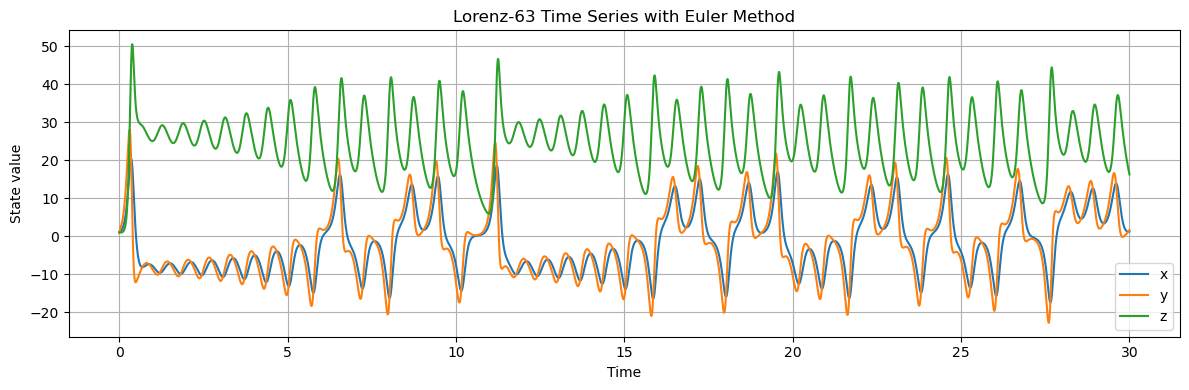

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_timeseries_euler.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time, trajectory[:, 0], label="x")
ax.plot(time, trajectory[:, 1], label="y")
ax.plot(time, trajectory[:, 2], label="z")

ax.set_xlabel("Time")
ax.set_ylabel("State value")
ax.set_title("Lorenz-63 Time Series with Euler Method")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "01_lorenz63_timeseries_euler.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 10. 변수별 시계열 따로 보기

세 변수를 한 그림에 함께 그리면 전체적인 변화를 보기에는 좋지만, 각 변수의 세부 변화를 보기 어려울 수 있다.

따라서 `x`, `y`, `z`를 각각 따로 그려본다.

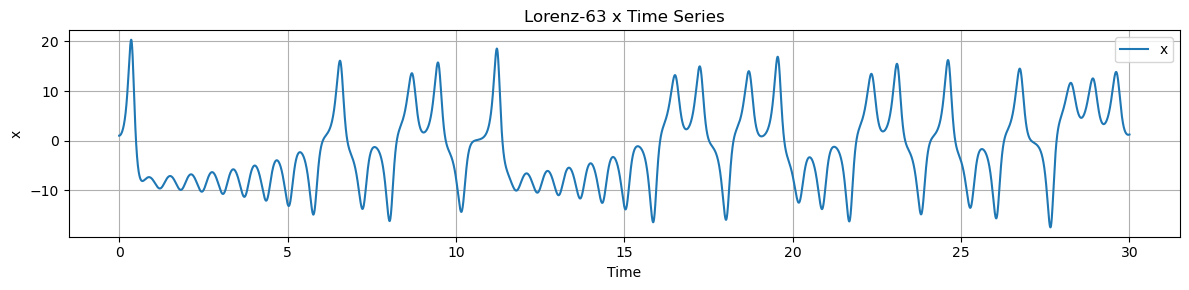

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_x_timeseries_euler.png


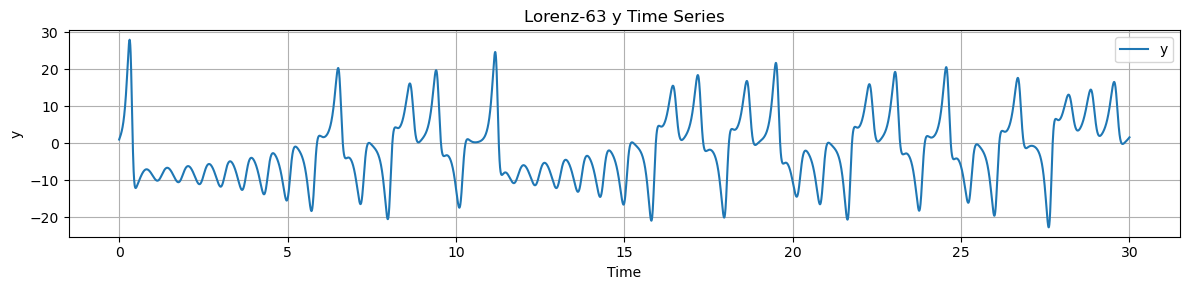

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_y_timeseries_euler.png


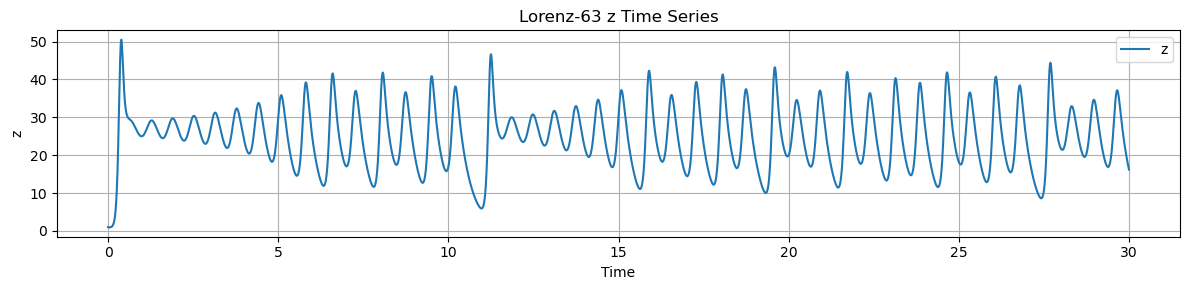

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_z_timeseries_euler.png


In [10]:
var_names = ["x", "y", "z"]

for i, name in enumerate(var_names):
    fig, ax = plt.subplots(figsize=(12, 3))

    ax.plot(time, trajectory[:, i], label=name)

    ax.set_xlabel("Time")
    ax.set_ylabel(name)
    ax.set_title(f"Lorenz-63 {name} Time Series")
    ax.legend()
    ax.grid(True)

    fig.tight_layout()

    fig_path = FIGURE_DIR / f"01_lorenz63_{name}_timeseries_euler.png"
    fig.savefig(fig_path, dpi=150)

    plt.show()

    print("Saved figure:", fig_path)

## 11. Lorenz attractor 시각화

Lorenz-63 시스템의 trajectory를 3차원 상태공간에서 그리면 butterfly-shaped attractor가 나타난다.

여기서 축은 각각 다음을 의미한다.

- x-axis: `x`
- y-axis: `y`
- z-axis: `z`

이 그림은 Lorenz-63 시스템이 단순한 주기운동이 아니라 복잡한 chaotic behavior를 가진다는 것을 보여준다.

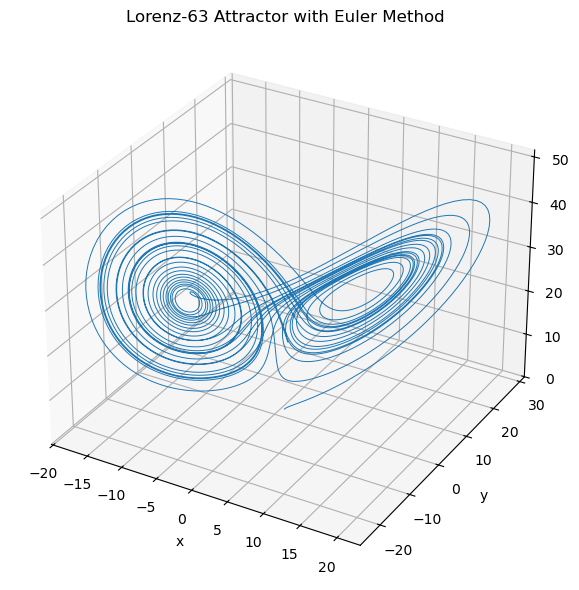

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_attractor_euler.png


In [11]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    trajectory[:, 2],
    linewidth=0.7,
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz-63 Attractor with Euler Method")

fig.tight_layout()

fig_path = FIGURE_DIR / "01_lorenz63_attractor_euler.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 12. 초기조건 민감도 실험

Lorenz-63 시스템의 중요한 특징은 초기조건 민감도이다.

이번에는 기준 초기조건과 거의 같은 초기조건을 하나 더 만든다.

기준 초기조건:

$$
\mathbf{x}_0 = [1, 1, 1]
$$

조금 perturbation을 준 초기조건:

$$
\mathbf{x}_0' = [1 + 10^{-6}, 1, 1]
$$

두 초기조건의 차이는 매우 작지만, 시간이 지나면서 두 trajectory가 크게 달라지는지 확인한다.

In [12]:
# 기준 초기조건
# x0_ref = np.array([1.0, 1.0, 1.0])
x0_ref = lorenz63_default_initial_condition()

# 아주 작은 perturbation을 준 초기조건
epsilon = 1.0e-6
x0_pert = np.array([1.0 + epsilon, 1.0, 1.0])

# 두 trajectory 계산
# trajectory_ref = integrate_euler(x0_ref, dt, nsteps)
# trajectory_pert = integrate_euler(x0_pert, dt, nsteps)
trajectory_ref = integrate_euler(
    x0=x0_ref,
    dt=dt,
    nsteps=nsteps,
    rhs_func=lorenz63_rhs,
)

trajectory_pert = integrate_euler(
    x0=x0_pert,
    dt=dt,
    nsteps=nsteps,
    rhs_func=lorenz63_rhs,
)

print("Reference initial condition:", x0_ref)
print("Perturbed initial condition:", x0_pert)
print("Initial difference:", np.linalg.norm(x0_pert - x0_ref))

Reference initial condition: [1. 1. 1.]
Perturbed initial condition: [1.000001 1.       1.      ]
Initial difference: 9.999999999177334e-07


## 13. 두 trajectory의 시계열 비교

기준 trajectory와 perturbation trajectory를 비교한다.

처음에는 거의 같은 값을 가지지만, 시간이 지나면서 차이가 커지는지 확인한다.

먼저 `x` 변수에 대해 비교한다.

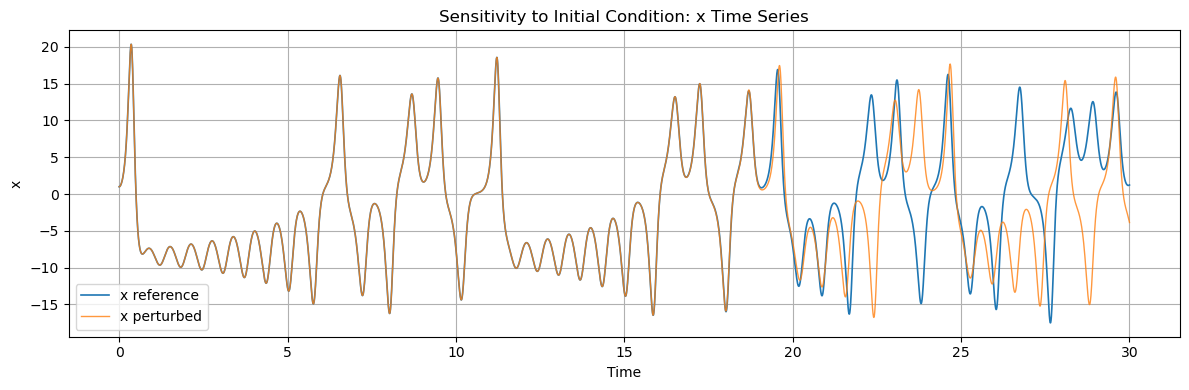

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_initial_sensitivity_x.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time, trajectory_ref[:, 0], label="x reference", linewidth=1.2)
ax.plot(time, trajectory_pert[:, 0], label="x perturbed", linewidth=1.0, alpha=0.8)

ax.set_xlabel("Time")
ax.set_ylabel("x")
ax.set_title("Sensitivity to Initial Condition: x Time Series")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "01_lorenz63_initial_sensitivity_x.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 14. 두 trajectory 사이의 거리 계산

두 trajectory 사이의 차이를 다음과 같이 계산한다.

$$
d(t) =
\left\|
\mathbf{x}_{ref}(t) - \mathbf{x}_{pert}(t)
\right\|_2
$$

여기서 $\|\cdot\|_2$는 Euclidean norm이다.

이 값이 시간이 지나면서 증가하면 초기조건의 작은 차이가 점점 증폭된다는 의미이다.

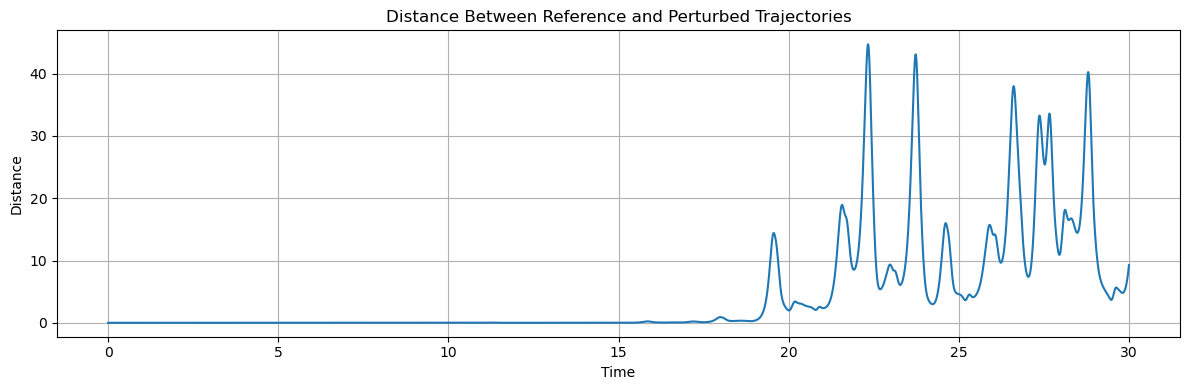

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_initial_sensitivity_distance.png
Initial distance: 9.999999999177334e-07
Final distance: 9.256082361464237


In [14]:
distance = np.linalg.norm(trajectory_ref - trajectory_pert, axis=1)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time, distance)

ax.set_xlabel("Time")
ax.set_ylabel("Distance")
ax.set_title("Distance Between Reference and Perturbed Trajectories")
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "01_lorenz63_initial_sensitivity_distance.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)
print("Initial distance:", distance[0])
print("Final distance:", distance[-1])

## 15. 거리 증가를 로그 스케일로 확인

초기에는 두 trajectory의 거리가 매우 작다.

이런 경우 일반 선형축보다 로그축이 차이의 성장을 확인하기 좋다.

아래 그림에서는 y축을 log scale로 설정한다.

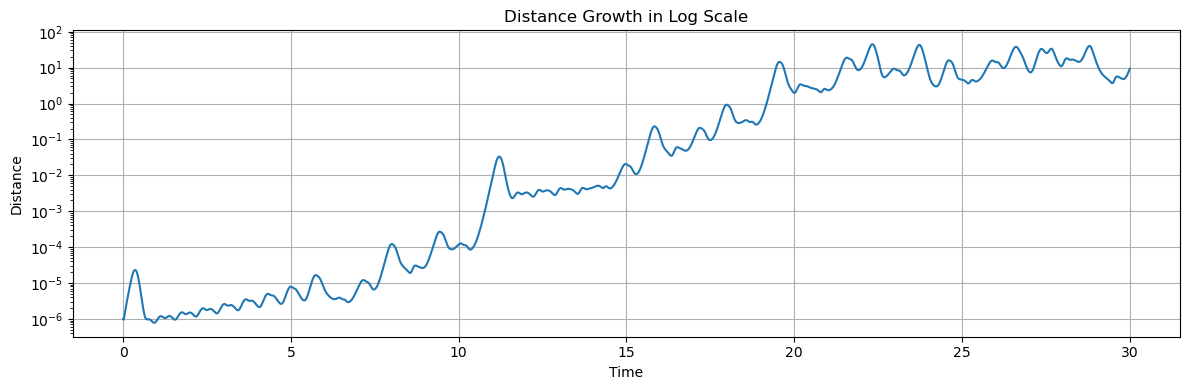

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_initial_sensitivity_distance_log.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.semilogy(time, distance)

ax.set_xlabel("Time")
ax.set_ylabel("Distance")
ax.set_title("Distance Growth in Log Scale")
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "01_lorenz63_initial_sensitivity_distance_log.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 16. 상태공간에서 두 trajectory 비교

이번에는 두 trajectory를 3차원 상태공간에서 함께 그려본다.

처음에는 두 trajectory가 거의 겹치지만, 시간이 지나면서 서로 다른 경로를 따라가게 된다.

이것이 chaotic system의 대표적인 특징이다.

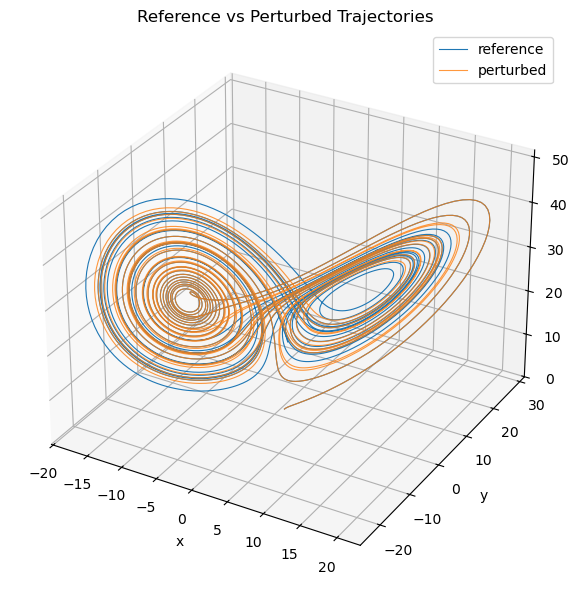

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_reference_vs_perturbed_attractor.png


In [16]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    trajectory_ref[:, 0],
    trajectory_ref[:, 1],
    trajectory_ref[:, 2],
    label="reference",
    linewidth=0.8,
)

ax.plot(
    trajectory_pert[:, 0],
    trajectory_pert[:, 1],
    trajectory_pert[:, 2],
    label="perturbed",
    linewidth=0.8,
    alpha=0.8,
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Reference vs Perturbed Trajectories")
ax.legend()

fig.tight_layout()

fig_path = FIGURE_DIR / "01_lorenz63_reference_vs_perturbed_attractor.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 17. 시간간격 dt 변화 실험

Euler 방법은 시간간격 `dt`에 민감하다.

이번에는 서로 다른 `dt`를 사용했을 때 trajectory가 어떻게 달라지는지 확인한다.

비교할 시간간격은 다음과 같다.

- `dt = 0.01`
- `dt = 0.005`
- `dt = 0.001`

단, `dt`가 작아질수록 계산량은 증가한다.

In [17]:
dt_list = [0.01, 0.005, 0.001]
tmax_dt_test = 10.0

dt_test_results = {}

for dt_test in dt_list:
    nsteps_test = int(tmax_dt_test / dt_test)
    time_test = np.arange(nsteps_test + 1) * dt_test

    # traj_test = integrate_euler(x0_ref, dt_test, nsteps_test)
    traj_test = integrate_euler(
    x0=x0_ref,
    dt=dt_test,
    nsteps=nsteps_test,
    rhs_func=lorenz63_rhs,
    )

    dt_test_results[dt_test] = {
        "time": time_test,
        "trajectory": traj_test,
    }

    print(f"dt = {dt_test}, nsteps = {nsteps_test}, final state = {traj_test[-1]}")

dt = 0.01, nsteps = 1000, final state = [ 8.88616658  6.09143734 30.72027943]
dt = 0.005, nsteps = 2000, final state = [ -7.48080603 -12.15240957  16.94496215]
dt = 0.001, nsteps = 10000, final state = [-4.39795654 -3.8409108  23.22485342]


## 18. dt 변화에 따른 x 시계열 비교

서로 다른 시간간격으로 적분한 결과의 `x` 시계열을 비교한다.

Euler 방법에서는 `dt`가 작을수록 더 정확한 결과를 기대할 수 있다.  
하지만 Lorenz-63은 chaotic system이므로, 시간이 충분히 지나면 작은 수치오차도 trajectory 차이를 크게 만들 수 있다.

따라서 장시간 trajectory를 점별로 완전히 일치시키는 것보다는, 전체적인 attractor 구조와 통계적 특성을 보는 것이 더 적절하다.

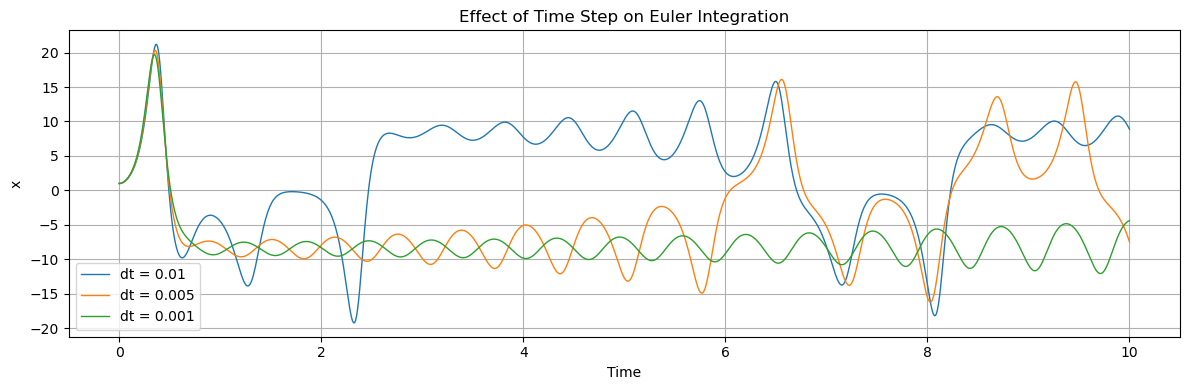

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_dt_comparison_x.png


In [18]:
fig, ax = plt.subplots(figsize=(12, 4))

for dt_test in dt_list:
    time_test = dt_test_results[dt_test]["time"]
    traj_test = dt_test_results[dt_test]["trajectory"]

    ax.plot(time_test, traj_test[:, 0], label=f"dt = {dt_test}", linewidth=1.0)

ax.set_xlabel("Time")
ax.set_ylabel("x")
ax.set_title("Effect of Time Step on Euler Integration")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "01_lorenz63_dt_comparison_x.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 19. dt 변화에 따른 attractor 비교

이번에는 서로 다른 `dt`로 계산한 trajectory를 3차원 상태공간에서 비교한다.

짧은 시간에서는 trajectory가 비슷하게 보일 수 있지만, 시간이 길어질수록 수치오차와 초기조건 민감도 때문에 서로 다른 궤적을 따라갈 수 있다.

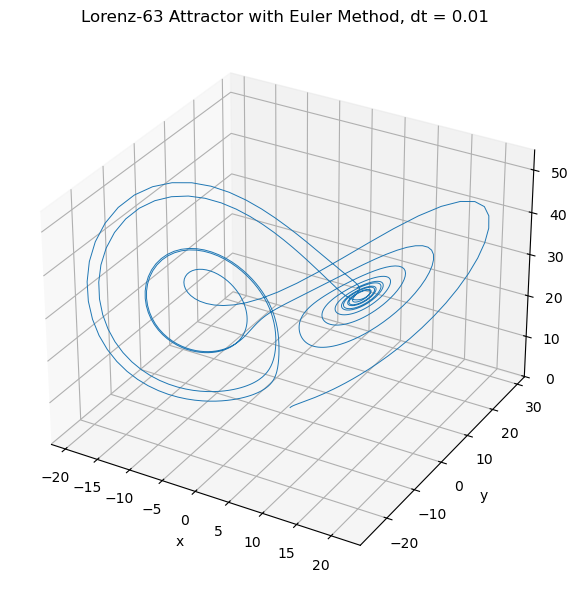

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_attractor_euler_dt_0p01.png


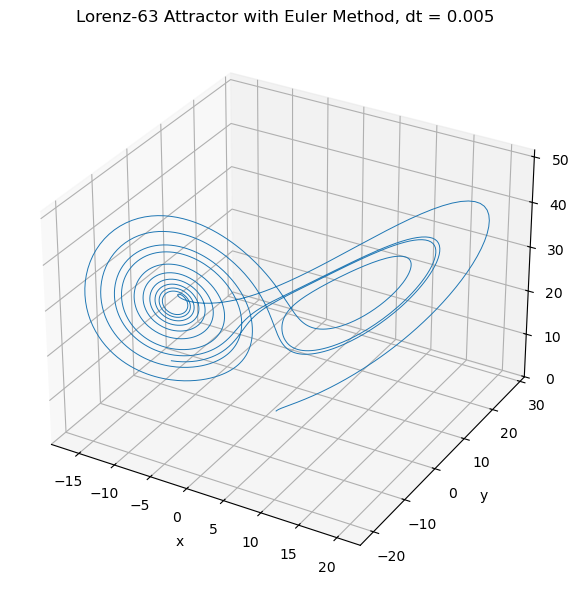

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_attractor_euler_dt_0p005.png


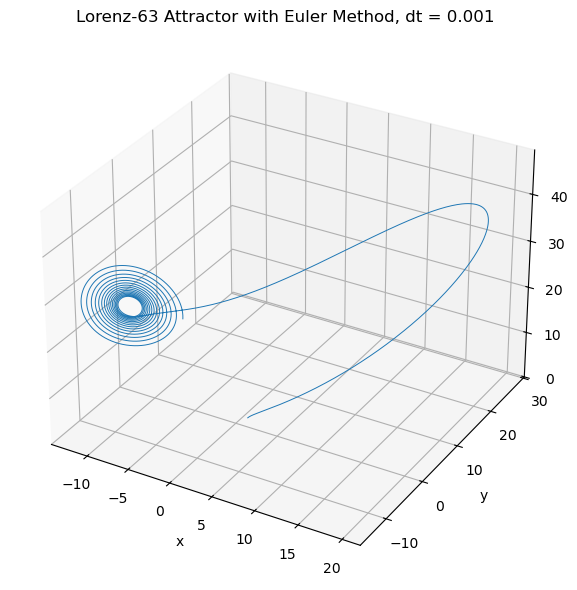

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/01_lorenz63_attractor_euler_dt_0p001.png


In [19]:
for dt_test in dt_list:
    traj_test = dt_test_results[dt_test]["trajectory"]

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(
        traj_test[:, 0],
        traj_test[:, 1],
        traj_test[:, 2],
        linewidth=0.7,
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"Lorenz-63 Attractor with Euler Method, dt = {dt_test}")

    fig.tight_layout()

    dt_label = str(dt_test).replace(".", "p")
    fig_path = FIGURE_DIR / f"01_lorenz63_attractor_euler_dt_{dt_label}.png"
    fig.savefig(fig_path, dpi=150)

    plt.show()

    print("Saved figure:", fig_path)

## 20. 이번 실습 정리

이번 노트북에서는 Lorenz-63 forward model을 Euler 방법으로 적분했다.

확인한 내용은 다음과 같다.

1. Lorenz-63 방정식은 세 변수 `x`, `y`, `z`로 구성된 비선형 동역학계이다.
2. Euler 방법은 가장 단순한 시간적분 방법이다.
3. Lorenz-63 시스템은 시간에 따라 복잡한 trajectory를 만든다.
4. 3차원 상태공간에서는 Lorenz attractor가 나타난다.
5. 초기조건에 아주 작은 차이를 주어도 시간이 지나면 trajectory가 크게 달라진다.
6. Euler 방법에서는 시간간격 `dt` 선택이 중요하다.

이번 실습에서 만든 trajectory는 이후 자료동화 실습에서 synthetic truth로 사용할 수 있다.

다음 실습에서는 이 truth에 인위적인 관측오차를 추가하여 synthetic observation을 만들고, 3D-Var 자료동화를 수행한다.

In [20]:
print("실습 완료")
print("저장된 trajectory:", trajectory_path)
print("저장된 time array:", time_path)
print("figure directory:", FIGURE_DIR)

실습 완료
저장된 trajectory: /Users/sanggyu/projects/lorenz-da-lab/outputs/trajectories/lorenz63_truth_euler_dt0005_tmax30.npy
저장된 time array: /Users/sanggyu/projects/lorenz-da-lab/outputs/trajectories/lorenz63_time_dt0005_tmax30.npy
figure directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures
